In [41]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import random

# 1. Generate Mock Users
np.random.seed(42)
users_data = {
    'user_id': range(1, 101), # 100 users
    'name': [f"Coder_{i}" for i in range(1, 101)],
    'experience_level': np.random.choice(['Beginner', 'Intermediate', 'Advanced', None], 100) # Introducing NaNs
}
df_users = pd.DataFrame(users_data)

# 2. Generate Mock Friendships (Edges)
edges = []
for _ in range(300):
    u1, u2 = random.sample(range(1, 101), 2)
    edges.append((u1, u2))
df_friends = pd.DataFrame(edges, columns=['user1_id', 'user2_id']).drop_duplicates()

# 3. Generate Mock Page Likes
pages = ['Python_Delhi', 'React_Devs', 'AI_Noida', 'DSA_Geeks', 'Cloud_Arch']
likes = []
for _ in range(250):
    likes.append((random.choice(range(1, 101)), random.choice(pages)))
df_likes = pd.DataFrame(likes, columns=['user_id', 'page_name']).drop_duplicates()

print("Mock data generated successfully!")

Mock data generated successfully!


In [42]:
# Clean User Data: Fill missing experience levels with the mode
mode_exp = df_users['experience_level'].mode()[0]
df_users['experience_level'] = df_users['experience_level'].fillna(mode_exp)

# Memory Optimization: Downcast integers
df_users['user_id'] = pd.to_numeric(df_users['user_id'], downcast='integer')
df_friends['user1_id'] = pd.to_numeric(df_friends['user1_id'], downcast='integer')
df_friends['user2_id'] = pd.to_numeric(df_friends['user2_id'], downcast='integer')
df_likes['user_id'] = pd.to_numeric(df_likes['user_id'], downcast='integer')

# Ensure friendship graph is undirected (if A is friends with B, B is friends with A)
reverse_friends = df_friends.rename(columns={'user1_id': 'user2_id', 'user2_id': 'user1_id'})
df_friends_full = pd.concat([df_friends, reverse_friends]).drop_duplicates()

print(f"Cleaned Users: {df_users.shape[0]}, Friend Connections: {df_friends_full.shape[0]}, Total Likes: {df_likes.shape[0]}")

Cleaned Users: 100, Friend Connections: 582, Total Likes: 191


In [43]:
# Build the Social Graph
G = nx.from_pandas_edgelist(df_friends_full, 'user1_id', 'user2_id')

def recommend_friends(target_user, graph, top_n=3):
    if target_user not in graph:
        return []

    target_friends = set(graph.neighbors(target_user))
    recommendations = []

    # Iterate through all nodes to find 2nd-degree connections
    for node in graph.nodes():
        if node == target_user or node in target_friends:
            continue # Skip self and existing friends

        node_friends = set(graph.neighbors(node))

        # Calculate Jaccard Similarity mathematically
        intersection = len(target_friends.intersection(node_friends))
        union = len(target_friends.union(node_friends))

        if union > 0:
            jaccard_score = intersection / union
            if jaccard_score > 0:
                recommendations.append((node, jaccard_score))

    # Sort by highest score
    recommendations.sort(key=lambda x: x[1], reverse=True)
    return recommendations[:top_n]

# Test it on a random user
target_id = 10
recs = recommend_friends(target_id, G)
print(f"Friend Recommendations for Coder_{target_id}:")
for friend_id, score in recs:
    print(f" -> Coder_{friend_id} (Similarity Score: {score:.2f})")

Friend Recommendations for Coder_10:
 -> Coder_92 (Similarity Score: 0.21)
 -> Coder_77 (Similarity Score: 0.20)
 -> Coder_55 (Similarity Score: 0.19)


In [44]:
# Create a sparse User-Item Matrix (1 if liked, 0 if not)
df_likes['liked'] = 1
user_page_matrix = df_likes.pivot(index='user_id', columns='page_name', values='liked').fillna(0)

# Calculate Cosine Similarity between users
user_similarity = cosine_similarity(user_page_matrix)
user_similarity_df = pd.DataFrame(user_similarity, index=user_page_matrix.index, columns=user_page_matrix.index)

def recommend_pages(target_user, user_matrix, similarity_df, top_n=2):
    if target_user not in user_matrix.index:
        return ["Popular: Python_Delhi", "Popular: DSA_Geeks"] # Cold Start fallback

    # Get similar users (excluding self)
    similar_users = similarity_df[target_user].drop(target_user).sort_values(ascending=False)

    # Get pages the target user already likes
    liked_pages = set(user_matrix.loc[target_user][user_matrix.loc[target_user] == 1].index)

    recommendations = {}
    for sim_user, sim_score in similar_users.items():
        if sim_score == 0: continue

        # Get pages this similar user liked
        sim_user_likes = user_matrix.loc[sim_user][user_matrix.loc[sim_user] == 1].index

        for page in sim_user_likes:
            if page not in liked_pages:
                # Weighted recommendation score based on user similarity
                recommendations[page] = recommendations.get(page, 0) + sim_score

    # Sort pages by accumulated score
    sorted_recs = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)
    return [page for page, score in sorted_recs[:top_n]]

# Test page recommendations
page_recs = recommend_pages(target_id, user_page_matrix, user_similarity_df)
print(f"\nPage Recommendations for Coder_{target_id}:")
for page in page_recs:
    print(f" -> {page}")


Page Recommendations for Coder_10:
 -> Python_Delhi
 -> React_Devs


In [45]:
import plotly.graph_objects as go

# 1. Generate positions for all nodes using a spring layout
pos = nx.spring_layout(G, seed=42)

# 2. Extract edge coordinates
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

# Create edge traces
edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines')

# 3. Extract node coordinates
node_x = []
node_y = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(
        showscale=True,
        colorscale='YlGnBu',
        reversescale=True,
        color=[],
        size=10,
        colorbar=dict(
            thickness=15,
            title=dict(
                text='Number of Connections',
                side='right'
            ),
            xanchor='left'
        ),
        line_width=2
    )
)

# 4. Color nodes by their degree (number of friends)
node_adjacencies = []
node_text = []
for node, adjacencies in enumerate(G.adjacency()):
    node_adjacencies.append(len(adjacencies[1]))
    node_text.append(f'Coder_{adjacencies[0]} - Connections: {len(adjacencies[1])}')

node_trace.marker.color = node_adjacencies
node_trace.text = node_text

fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title=dict(
            text='<br>Coders of Delhi: Social Network Graph',
            font=dict(size=16)
        ),
        showlegend=False,
        hovermode='closest',
        margin=dict(b=20, l=5, r=5, t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
    )
)

fig.show()

C:\Users\shiva\AppData\Local\Temp\ipykernel_21940\2378442481.py:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




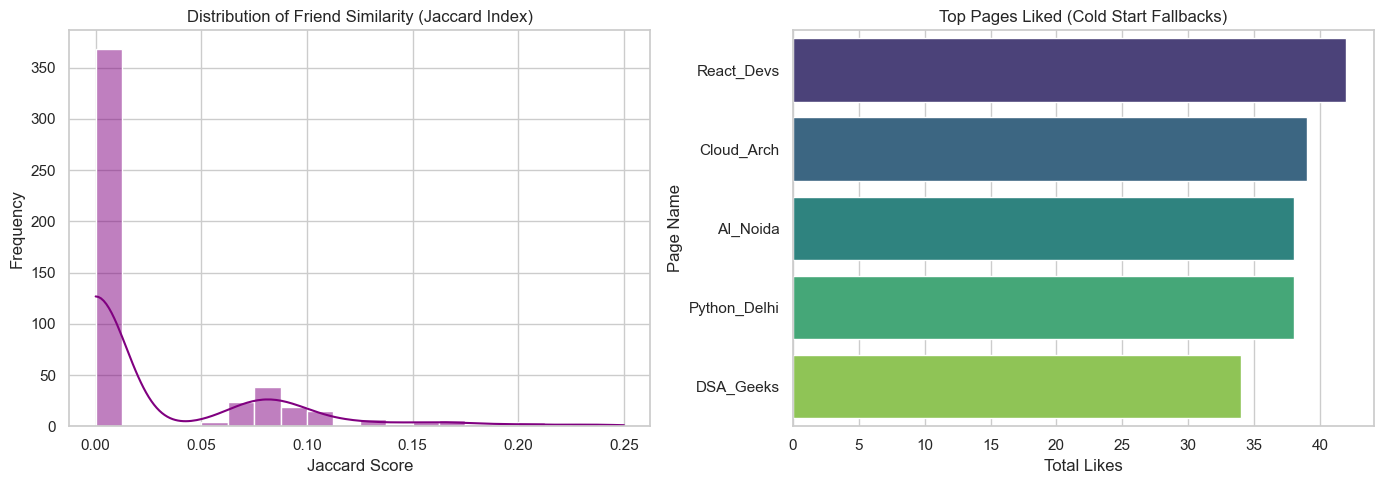

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the matplotlib figure
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Plot 1: Distribution of Jaccard Similarity Scores in our sample
# We will sample 500 random pairs to get a sense of the network's density
sample_jaccard = []
nodes = list(G.nodes())
for _ in range(500):
    n1, n2 = random.sample(nodes, 2)
    n1_friends = set(G.neighbors(n1))
    n2_friends = set(G.neighbors(n2))
    union = len(n1_friends.union(n2_friends))
    if union > 0:
        sample_jaccard.append(len(n1_friends.intersection(n2_friends)) / union)

plt.subplot(1, 2, 1)
sns.histplot(sample_jaccard, bins=20, kde=True, color='purple')
plt.title('Distribution of Friend Similarity (Jaccard Index)')
plt.xlabel('Jaccard Score')
plt.ylabel('Frequency')

# Plot 2: Most Popular Pages (The "Cold Start" Fallback options)
plt.subplot(1, 2, 2)
page_popularity = df_likes['page_name'].value_counts()
sns.barplot(x=page_popularity.values, y=page_popularity.index, palette="viridis")
plt.title('Top Pages Liked (Cold Start Fallbacks)')
plt.xlabel('Total Likes')
plt.ylabel('Page Name')

plt.tight_layout()
plt.show()